# Klasifikacija organic vs campaign korisnika

Predvidjeti je li korisnik organic ili dosao iz placene kampanje, na temelju akcija u 30 dana.

Kljucni uvidi:

- Label campaign: `<organic>` (mozda noisy), sve ostalo je sigurno kampanja
- 43.3% organic
- Campaign rate po drzavama: Haiti 1.4%, Brazil 74%, Morocco 83%
- 4 kolone bez varijance (`avg_open_overs`, `avg_open_sport`, `avg_open_fight_night`, `avg_open_stage`)

LightGBM s native categorical `geo_country` jer je 195 kategorija previse za one-hot + Optuna za hiperparametre


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    log_loss,
)

import warnings

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

SEED = 42
np.random.seed(SEED)

## 1. Ucitavanje i label definicija


In [2]:
with open("dataset_academy.pickle", "rb") as f:
    df = pickle.load(f)

df["is_campaign"] = (df["campaign"] != "<organic>").astype(int)

print("Shape:", df.shape)
print(df["is_campaign"].value_counts(normalize=True))

Shape: (126870, 23)
is_campaign
1   0.5664
0   0.4336
Name: proportion, dtype: float64


## 2. Quick EDA

Provjera distribucije po drzavama


In [3]:
top_c = df["geo_country"].value_counts().head(15).index
print(
    df[df["geo_country"].isin(top_c)]
    .groupby("geo_country")["is_campaign"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
)

               mean  count
geo_country               
Brazil       0.7406  15369
Morocco      0.8298   8186
Nigeria      0.6775   6691
Haiti        0.0136   5717
Italy        0.6761   4415
India        0.3773   4230
Indonesia    0.6427   4223
Tanzania     0.7023   3759
Kenya        0.7205   3088
Ghana        0.6531   3021
South Africa 0.5962   2172
Spain        0.6100   2131
Türkiye      0.0281   2065
Bangladesh   0.3597   1899
France       0.4857   1894


## 3. Preprocessing


In [4]:
cols = [
    c
    for c in df.columns
    if c
    not in [
        "avg_open_overs",
        "avg_open_sport",
        "avg_open_fight_night",
        "avg_open_stage",
    ]
    + ["user_id", "campaign"]
    + ["is_campaign"]
]

print(f"Broj feature-a: {len(cols)}")
print(cols)

X = df[cols].copy()
y = df["is_campaign"].copy()
X["geo_country"] = X["geo_country"].astype("category")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=SEED
)

print(f"Train: {X_tr.shape}  Val: {X_val.shape}  Test: {X_te.shape}")
print(
    f"train/val/test: {y_tr.mean():.4f} / {y_val.mean():.4f} / {y_te.mean():.4f}"
)

Broj feature-a: 16
['avg_open_team', 'avg_open_event', 'avg_open_league', 'avg_open_player', 'avg_open_matches', 'avg_open_lineups', 'avg_follow_team', 'avg_follow_player', 'avg_follow_league', 'avg_chat_activity', 'avg_chat_action', 'avg_ads_impression_custom', 'avg_odds_impression', 'avg_total_screen_time', 'avg_num_distinct_events', 'geo_country']
Train: (86271, 16)  Val: (15225, 16)  Test: (25374, 16)
train/val/test: 0.5664 / 0.5664 / 0.5664


## 4. LightGBM

In [5]:
baseline = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
baseline.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="binary_logloss",
    categorical_feature=["geo_country"],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
print(f"Best iter: {baseline.best_iteration_}")

p_base = baseline.predict_proba(X_te)[:, 1]
yhat_base = (p_base >= 0.5).astype(int)
print(f"Precision: {precision_score(y_te, yhat_base):.4f}")
print(f"Recall:    {recall_score(y_te, yhat_base):.4f}")
print(f"F1:        {f1_score(y_te, yhat_base):.4f}")

Best iter: 151
Precision: 0.7431
Recall:    0.9159
F1:        0.8205


## 5. Optuna tuning

In [6]:
def objective(trial):
    params = {
        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 300),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="binary_logloss",
        categorical_feature=["geo_country"],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    return log_loss(y_val, m.predict_proba(X_val)[:, 1])

study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=40, show_progress_bar=False)
best_params = study.best_params

print("Parametri:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Parametri:
  learning_rate: 0.06432759992849894
  num_leaves: 99
  min_child_samples: 47
  subsample: 0.8736932106048627
  colsample_bytree: 0.7760609974958406


## 6. LightGBM s podesenim parametrima


In [7]:
full_params = {
    **best_params,
    "n_estimators": 3000,
    "random_state": SEED,
    "n_jobs": -1,
    "verbose": -1,
}
final_lgb = lgb.LGBMClassifier(**full_params)
final_lgb.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="binary_logloss",
    categorical_feature=["geo_country"],
    callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
)
print(f"Best iter: {final_lgb.best_iteration_}")

Best iter: 105


## 7. Threshold optimizacija

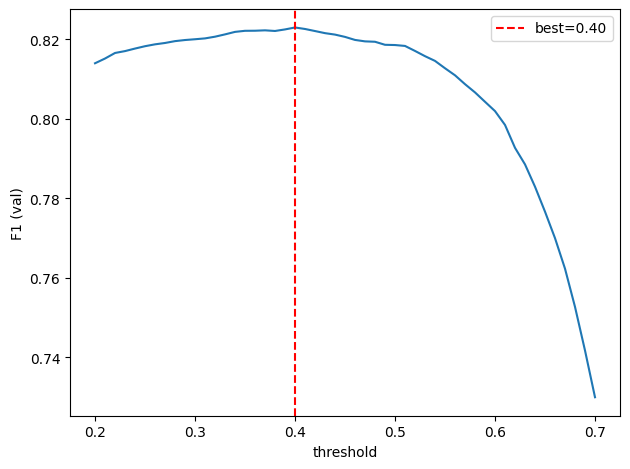

Optimalni: 0.40 (F1=0.8229)


In [8]:
p_val = final_lgb.predict_proba(X_val)[:, 1]
ths = np.arange(0.20, 0.71, 0.01)
f1s = [f1_score(y_val, (p_val >= t).astype(int)) for t in ths]
best_thr = ths[int(np.argmax(f1s))]

plt.figure()
plt.plot(ths, f1s)
plt.axvline(best_thr, color="red", linestyle="--", label=f"best={best_thr:.2f}")
plt.xlabel("threshold")
plt.ylabel("F1 (val)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimalni: {best_thr:.2f} (F1={max(f1s):.4f})")

## 8. XGBoost
XGBoost ne podrzava native categorical pa koristimo frequency encoding

In [9]:
freq = X_tr["geo_country"].value_counts().to_dict()
enc = lambda X: X.assign(geo_country=X["geo_country"].map(freq).fillna(0).astype(float))

xgb_model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=8,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="logloss",
    early_stopping_rounds=50,
    verbosity=0,
)
xgb_model.fit(enc(X_tr), y_tr, eval_set=[(enc(X_val), y_val)], verbose=False)

p_xgb_val = xgb_model.predict_proba(enc(X_val))[:, 1]
xgb_thr = ths[int(np.argmax([f1_score(y_val, (p_xgb_val >= t).astype(int)) for t in ths]))]

p_xgb_te = xgb_model.predict_proba(enc(X_te))[:, 1]
yhat_xgb = (p_xgb_te >= xgb_thr).astype(int)

print(f"XGBoost (thr={xgb_thr:.2f}):")
print(f"  Precision: {precision_score(y_te, yhat_xgb):.4f}")
print(f"  Recall:    {recall_score(y_te, yhat_xgb):.4f}")
print(f"  F1:        {f1_score(y_te, yhat_xgb):.4f}")

XGBoost (thr=0.43):
  Precision: 0.7277
  Recall:    0.9414
  F1:        0.8209


## 9. Evaluacija

Setting 1: cijeli test skup

Setting 2: samo sigurno-campaign korisnici (`y_test == 1`)


In [10]:
p_te = final_lgb.predict_proba(X_te)[:, 1]
yhat = (p_te >= best_thr).astype(int)

print("Cijeli test")
print("precision", round(precision_score(y_te, yhat), 4))
print("recall", round(recall_score(y_te, yhat), 4))
print("f1", round(f1_score(y_te, yhat), 4))
print(classification_report(y_te, yhat, digits=4))
print(confusion_matrix(y_te, yhat))

prec_c, rec_c, _ = precision_recall_curve(y_te, p_te)
print("pr-auc", round(auc(rec_c, prec_c), 4))

mask = (y_te == 1).values
rec2 = recall_score(y_te[mask], yhat[mask])
print("\nSamo non-organic")
print("recall", round(rec2, 4))
print(f"uhvaceno {yhat[mask].sum()} / {mask.sum()}")

Cijeli test
precision 0.7262
recall 0.9513
f1 0.8237
              precision    recall  f1-score   support

           0     0.8931    0.5315    0.6664     11002
           1     0.7262    0.9513    0.8237     14372

    accuracy                         0.7693     25374
   macro avg     0.8097    0.7414    0.7451     25374
weighted avg     0.7986    0.7693    0.7555     25374

[[ 5848  5154]
 [  700 13672]]
pr-auc 0.8175

Samo non-organic
recall 0.9513
uhvaceno 13672 / 14372


## 10. Feature importance

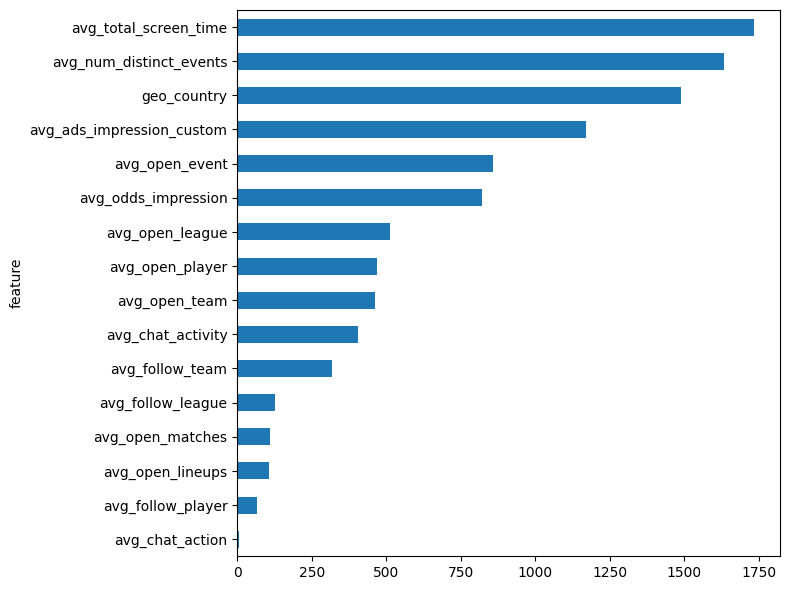

                  feature  importance
    avg_total_screen_time        1735
  avg_num_distinct_events        1634
              geo_country        1490
avg_ads_impression_custom        1169
           avg_open_event         860
      avg_odds_impression         823
          avg_open_league         513
          avg_open_player         469
            avg_open_team         461
        avg_chat_activity         404
          avg_follow_team         318
        avg_follow_league         125
         avg_open_matches         109
         avg_open_lineups         108
        avg_follow_player          67
          avg_chat_action           5


In [11]:
fi = pd.DataFrame(
    {
        "feature": final_lgb.feature_name_,
        "importance": final_lgb.feature_importances_,
    }
).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot.barh(x="feature", y="importance", ax=ax, legend=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(fi.to_string(index=False))

## 11. Spremanje modela


In [12]:
artifact = {
    "model": final_lgb,
    "threshold": float(best_thr),
    "cols": cols,
    "best_params": best_params,
    "drop_cols": [
        "avg_open_overs",
        "avg_open_sport",
        "avg_open_fight_night",
        "avg_open_stage",
    ],
}
with open("hw8_model.pkl", "wb") as f:
    pickle.dump(artifact, f)
print("Spremljen model i threshold u hw8_model.pkl")

Spremljen model i threshold u hw8_model.pkl


## Zakljucak

LightGBM daje F1 oko 0.82 na cijelom testu, a recall na sigurno-campaign
korisnicima oko 0.96.

geo_country je jedna od najjacih znacajki jer se campaign rate jako razlikuje
po drzavama. Uz nju najvise nose avg_num_distinct_events i avg_total_screen_time,
sto pokazuje da su campaign korisnici u prosjeku aktivniji u prvih 30 dana.

Optuna i optimizacija thresholda dale su tek mali pomak u odnosu na obican LightGBM.
XGBoost je dao slicne brojke, ali stavio sam LightGBM zbog boljeg rada s kategorijama.

Glavno ogranicenje je sto organic oznaka moze sadrzavati i neke campaign
korisnike, pa dio false positive-a u prvom settingu vjerojatno nisu prave greske.